# 02 - Exploratory Data Analysis

## Project
Telecom Customer Retention Intelligence Platform

### Purpose
The purpose of this notebook is to explore relationships between customer attributes and churn behavior through visual and statistical analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df.shape

(7043, 33)

# 1. Payment Method vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether different payment methods are associated with customer churn. Understanding this relationship may help identify customer payment behaviors linked to higher churn risk.

In [7]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### Observation

Customers using **Electronic check** exhibit the highest churn rate (**45.29%**), while customers using **automatic payment methods** (bank transfer or credit card) have significantly lower churn rates.

### Business Insight

Encouraging customers to adopt automatic payment methods may help reduce customer churn. Promotional campaigns or incentives for automatic payments could improve customer retention.

### Machine Learning Perspective

The **Payment Method** feature demonstrates a meaningful relationship with customer churn and should be included as an important categorical variable in the churn prediction model.

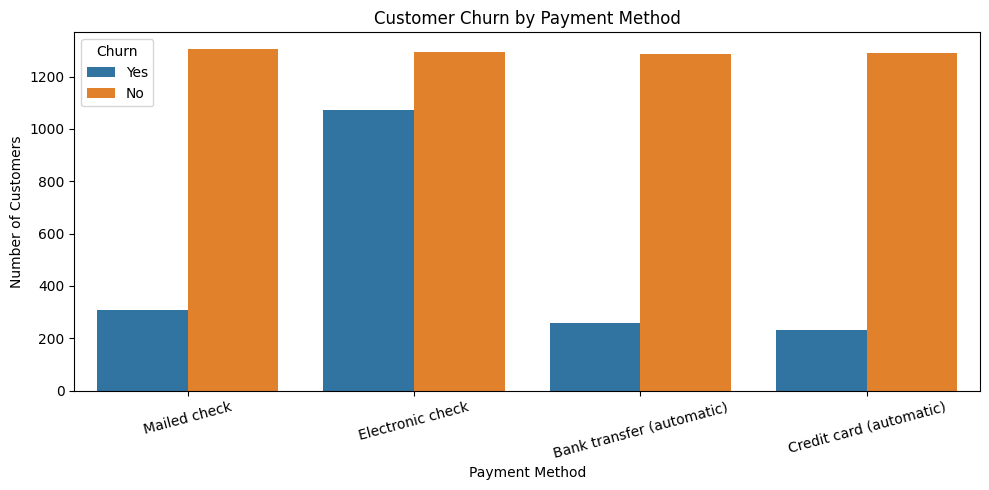

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

# 2. Monthly Charges vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether customers with higher monthly charges are more likely to churn. Understanding this relationship can help evaluate the impact of pricing on customer retention.

In [9]:
df.groupby("Churn Label")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


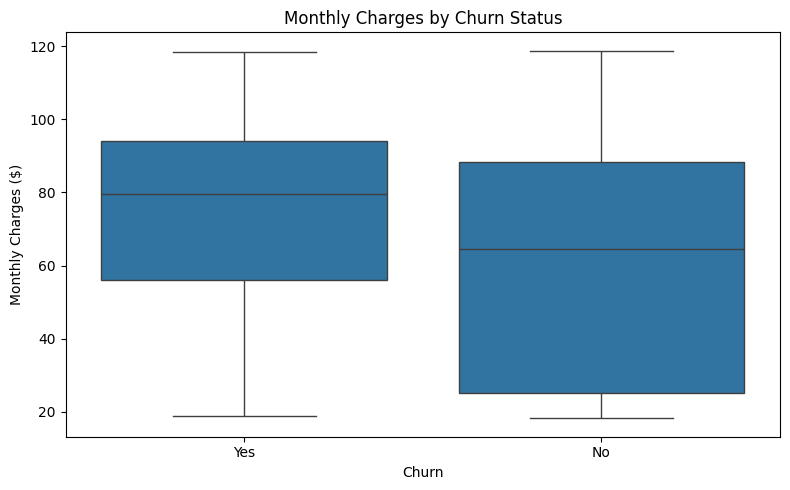

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

### Observation

Customers who churned tend to have higher monthly charges than customers who remained with the company. Both the average and median monthly charges are noticeably higher for churned customers.

### Business Insight

Higher monthly charges are associated with higher customer churn. The company should evaluate whether pricing, perceived value, or service quality influences customer decisions, especially among customers with premium plans.

### Machine Learning Perspective

The **Monthly Charges** feature demonstrates a meaningful relationship with customer churn and is expected to be an important numerical predictor in the churn prediction model.

# 3. Correlation Analysis

### Analysis Objective

The objective of this analysis is to examine the relationships between numerical variables in the dataset. Correlation analysis helps identify features that are strongly associated with customer churn and reveals potential relationships among numerical variables before model development.

In [11]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')

In [12]:
numeric_df = df[
    [
        "Tenure Months",
        "Monthly Charges",
        "Churn Value"
    ]
]

numeric_df.corr()

,Tenure Months,Monthly Charges,Churn Value
Tenure Months,1.000000,0.247900,-0.352229
Monthly Charges,0.247900,1.000000,0.193356
Churn Value,-0.352229,0.193356,1.000000


### Observation

The correlation matrix shows that **Tenure Months** has a moderate negative correlation with churn (-0.35), indicating that customers with longer tenure are less likely to leave the company. **Monthly Charges** has a weak positive correlation (0.19), suggesting that customers paying higher monthly fees tend to churn slightly more often.

### Business Insight

The company should prioritize retaining customers during their early months and closely monitor customers with higher monthly charges. Although pricing alone does not explain churn, it may contribute when combined with other factors.

### Machine Learning Perspective

Correlation analysis confirms that **Tenure Months** is one of the strongest numerical predictors of churn in the dataset. However, additional categorical features such as **Contract** and **Internet Service** are also expected to play a significant role during model training.

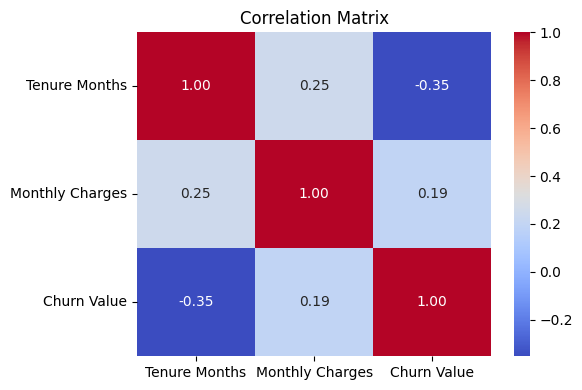

In [13]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Observation

The heatmap confirms that **Tenure Months** has the strongest numerical relationship with customer churn among the selected variables. Customers with longer tenure are less likely to churn, while **Monthly Charges** shows only a weak positive relationship with churn.

### Business Insight

Customer retention strategies should primarily focus on increasing customer longevity. Pricing alone is unlikely to explain churn; therefore, pricing strategies should be evaluated together with contract types, internet services, and customer satisfaction.

### Machine Learning Perspective

The correlation analysis validates previous findings from the exploratory analysis. **Tenure Months** is expected to be one of the most influential numerical features, while **Monthly Charges** may become more informative when combined with categorical variables during model training.

# 4. Senior Citizen vs Churn

### Analysis Objective

The objective of this analysis is to examine whether senior customers have a different churn behavior compared to non-senior customers.

In [14]:
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


### Observation

Senior customers exhibit a considerably higher churn rate (**41.68%**) compared to non-senior customers (**23.61%**). This suggests that customer age group may be associated with different retention behaviors.

### Business Insight

Telecom companies should consider developing targeted retention strategies for senior customers, such as simplified service plans, personalized customer support, and loyalty programs designed for this customer segment.

### Machine Learning Perspective

The **Senior Citizen** feature shows a meaningful relationship with customer churn and should be included as a binary feature in the predictive model.

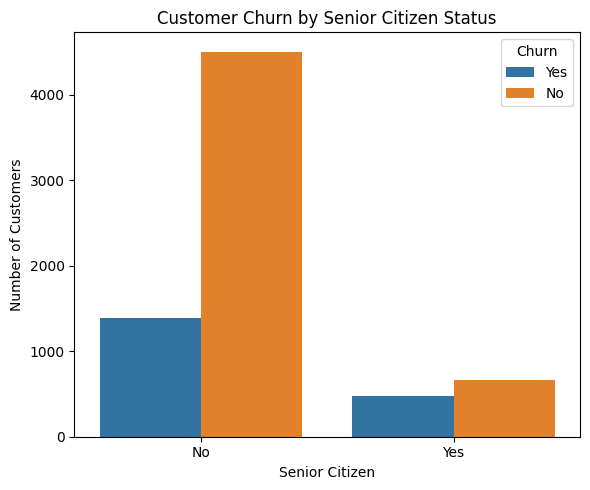

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Label"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")
plt.tight_layout()

plt.show()

### Observation

Senior customers exhibit a considerably higher churn rate (**41.68%**) compared to non-senior customers (**23.61%**). This suggests that customer age group may be associated with different retention behaviors.

### Business Insight

Telecom companies should consider developing targeted retention strategies for senior customers, such as simplified service plans, personalized customer support, and loyalty programs designed for this customer segment.

### Machine Learning Perspective

The **Senior Citizen** feature shows a meaningful relationship with customer churn and should be included as a binary feature in the predictive model.

# 5. Partner vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether having a partner is associated with customer churn behavior.

In [16]:
pd.crosstab(
    df["Partner"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


### Observation

Customers without a partner exhibit a noticeably higher churn rate (**32.96%**) compared to customers with a partner (**19.66%**). This suggests that partnership status may be associated with customer retention.

### Business Insight

Customers without partners may require additional engagement strategies. Family-oriented promotions, referral programs, or bundled service plans could help improve retention within this customer segment.

### Machine Learning Perspective

The **Partner** feature demonstrates a meaningful relationship with churn and should be included as a binary predictor in the machine learning model.

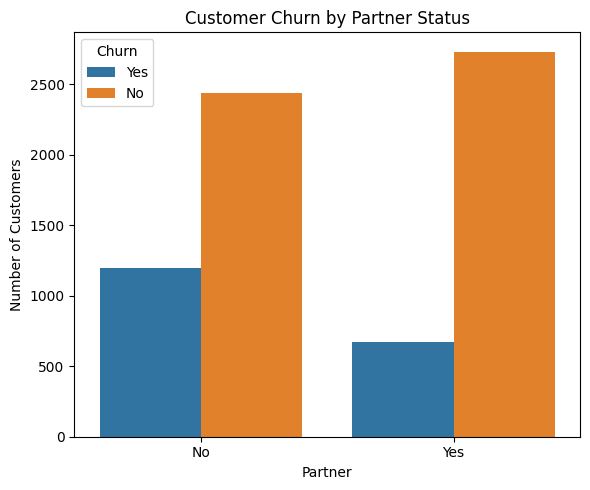

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn Label"
)

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### Observation

Customers without a partner exhibit a noticeably higher churn rate (**32.96%**) compared to customers with a partner (**19.66%**). This suggests that partnership status may be associated with customer retention.

### Business Insight

Customers without partners may require additional engagement strategies. Family-oriented promotions, referral programs, or bundled service plans could help improve retention within this customer segment.

### Machine Learning Perspective

The **Partner** feature demonstrates a meaningful relationship with churn and should be included as a binary predictor in the machine learning model.

In [18]:
pd.crosstab(
    df["Online Security"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Online Security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


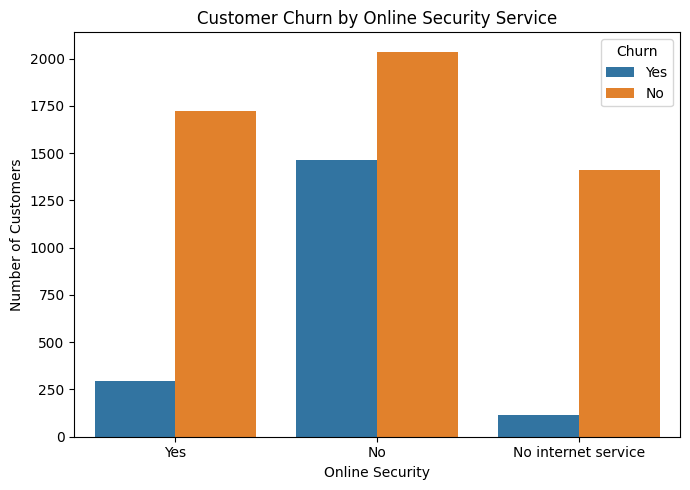

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Online Security",
    hue="Churn Label"
)

plt.title("Customer Churn by Online Security Service")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")
plt.tight_layout()

plt.show()

### Observation

Customers without the **Online Security** service exhibit a significantly higher churn rate (**41.77%**) compared to customers who subscribe to the service (**14.61%**). Customers without internet service have the lowest churn rate (**7.40%**), representing a distinct customer segment.

### Business Insight

The company should encourage customers to subscribe to the **Online Security** service through promotions, bundled packages, or free trial offers. Customers using additional value-added services appear to be more likely to remain with the company.

### Machine Learning Perspective

The **Online Security** feature demonstrates one of the strongest relationships with customer churn observed so far. It is expected to be one of the most influential categorical predictors during model training.

# 7. Tech Support vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether customers who subscribe to the Tech Support service are less likely to churn compared to customers without this service.

In [20]:
pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


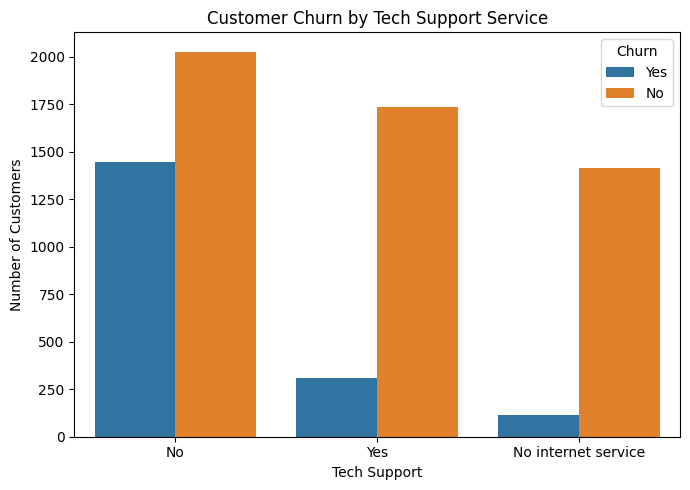

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Tech Support",
    hue="Churn Label"
)

plt.title("Customer Churn by Tech Support Service")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")
plt.tight_layout()

plt.show()

### Observation

Customers without the **Tech Support** service exhibit a significantly higher churn rate (**41.64%**) compared to customers who subscribe to the service (**15.17%**). Customers without internet service represent a separate customer group with a much lower churn rate.

### Business Insight

Providing or promoting **Tech Support** services may contribute to customer retention. Customers who do not use technical support services should be considered a priority group for retention campaigns.

### Machine Learning Perspective

The **Tech Support** feature demonstrates a very strong relationship with customer churn and is expected to be one of the most influential categorical features in the predictive model.

# 8. Dependents vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether customers with dependents exhibit different churn behavior compared to customers without dependents.

In [22]:
pd.crosstab(
    df["Dependents"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Dependents,,
No,67.448301,32.551699
Yes,93.484942,6.515058


### Observation

Customers with **dependents** exhibit a substantially lower churn rate (**6.52%**) compared to customers without dependents (**32.55%**). This indicates a strong relationship between dependent status and customer retention.

### Business Insight

Customers without dependents may represent a higher-risk customer segment. The company could target these customers with personalized retention campaigns, loyalty rewards, or bundled service offerings.

### Machine Learning Perspective

The **Dependents** feature demonstrates a very strong relationship with customer churn and is expected to be an important binary predictor in the machine learning model.

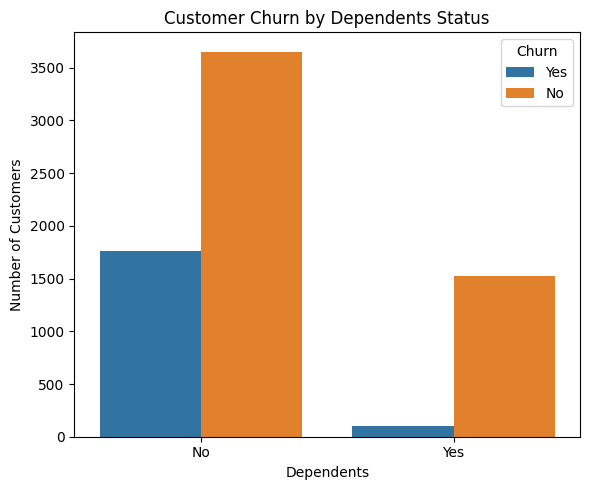

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn Label"
)

plt.title("Customer Churn by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")
plt.tight_layout()

plt.show()

### Observation

Customers with **dependents** exhibit a substantially lower churn rate (**6.52%**) compared to customers without dependents (**32.55%**). This indicates a strong relationship between dependent status and customer retention.

### Business Insight

Customers without dependents may represent a higher-risk customer segment. The company could target these customers with personalized retention campaigns, loyalty rewards, or bundled service offerings.

### Machine Learning Perspective

The **Dependents** feature demonstrates a very strong relationship with customer churn and is expected to be an important binary predictor in the machine learning model.

# 9. Gender vs Churn

### Analysis Objective

The objective of this analysis is to investigate whether customer gender is associated with churn behavior.

In [24]:
pd.crosstab(
    df["Gender"],
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


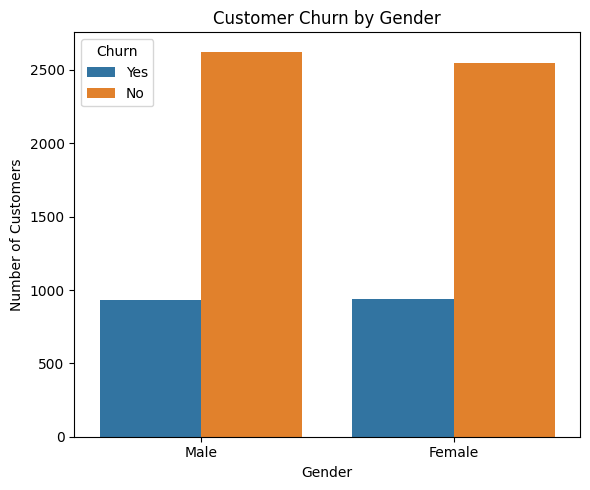

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Label"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Churn")
plt.tight_layout()

plt.show()

### Observation

The churn rates for female (**26.92%**) and male (**26.16%**) customers are nearly identical. This indicates that gender has little observable relationship with customer churn in this dataset.

### Business Insight

Since churn behavior appears to be similar across genders, retention strategies should focus on more influential factors such as contract type, service usage, and customer tenure rather than customer gender.

### Machine Learning Perspective

The **Gender** feature is expected to have relatively low predictive importance compared to other features analyzed during the exploratory data analysis.

# Exploratory Data Analysis Summary

## Key Findings

- Customers with month-to-month contracts have the highest churn rate.
- Customers with shorter tenure are significantly more likely to churn.
- Higher monthly charges are associated with higher churn.
- Customers using Electronic Check exhibit the highest churn rate among payment methods.
- Customers without Online Security or Tech Support services have substantially higher churn rates.
- Customers without dependents have significantly higher churn rates than customers with dependents.
- Senior customers are more likely to churn than non-senior customers.
- Customers without partners show a moderately higher churn rate.
- Gender has little observable relationship with customer churn.

## Candidate Features for Machine Learning

The following features demonstrated meaningful relationships with customer churn and are expected to contribute to the predictive model:

- Contract
- Tenure Months
- Monthly Charges
- Internet Service
- Online Security
- Tech Support
- Payment Method
- Dependents
- Senior Citizen
- Partner

The Gender feature showed minimal association with churn and is expected to have relatively low predictive importance.

## Conclusion

The exploratory data analysis identified several important factors associated with customer churn. Contract type, customer tenure, value-added services, and household characteristics appear to be the strongest predictors. These findings will guide the data preprocessing, feature engineering, and machine learning stages of the project.